# Credit Scoring - Prédiction du risque de défaut

**Objectif** : Prédire si un client va faire défaut sur son crédit.
**Dataset** : German Credit Data (UCI) - 1000 clients, 20 features
**Modèles** : Logistic Regression, Random Forest, XGBoost
**Techniques** : SMOTE (déséquilibre), SHAP (interprétabilité)

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_data, prepare_data
from model import get_models, train_model, tune_xgboost
from evaluation import evaluate_model, plot_roc_curves, plot_confusion_matrix

%matplotlib inline
sns.set_style("whitegrid")

In [2]:
# 1. Chargement des données
df = load_data("../data/german_credit.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


Distribution de la cible :
default
0    0.7
1    0.3
Name: proportion, dtype: float64


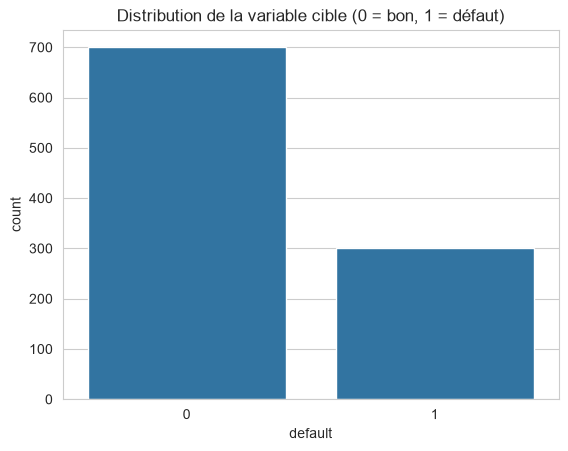

In [3]:
# 2. Exploration de la variable cible
print("Distribution de la cible :")
print(df["default"].value_counts(normalize=True))

sns.countplot(x="default", data=df)
plt.title("Distribution de la variable cible (0 = bon, 1 = défaut)")
plt.show()

In [4]:
# 3. Préparation des données (split + preprocessing + SMOTE)
X_train, X_test, y_train, y_test, preprocessor = prepare_data(df, target_col="default")
print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"Distribution train après SMOTE : {np.bincount(y_train)}")

Train : (1120, 61)
Test  : (200, 61)
Distribution train après SMOTE : [560 560]


In [5]:
# 4. Entraînement des modèles
models = get_models()
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Entraînement : {name}")
    print('='*50)
    trained = train_model(model, X_train, y_train)
    auc, y_proba = evaluate_model(trained, X_test, y_test, model_name=name)
    results[name] = (y_test, y_proba)


Entraînement : LogisticRegression

===== LogisticRegression =====
              precision    recall  f1-score   support

           0       0.89      0.73      0.80       140
           1       0.55      0.78      0.65        60

    accuracy                           0.74       200
   macro avg       0.72      0.76      0.72       200
weighted avg       0.79      0.74      0.75       200

ROC-AUC: 0.7967

Entraînement : RandomForest

===== RandomForest =====
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       140
           1       0.64      0.45      0.53        60

    accuracy                           0.76       200
   macro avg       0.72      0.67      0.68       200
weighted avg       0.75      0.76      0.75       200

ROC-AUC: 0.7876

Entraînement : XGBoost


c:\Users\solinfo\Documents\Credit-scoring\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:21:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost =====
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       140
           1       0.56      0.50      0.53        60

    accuracy                           0.73       200
   macro avg       0.68      0.66      0.67       200
weighted avg       0.72      0.73      0.73       200

ROC-AUC: 0.7723


In [6]:
# 5. Tuning XGBoost (GridSearchCV)
best_xgb, best_params = tune_xgboost(X_train, y_train)
print("Meilleurs paramètres XGBoost :", best_params)

auc_xgb, y_proba_xgb = evaluate_model(best_xgb, X_test, y_test, model_name="XGBoost Tuned")
results["XGBoost Tuned"] = (y_test, y_proba_xgb)

c:\Users\solinfo\Documents\Credit-scoring\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:22:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Meilleurs paramètres XGBoost : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}

===== XGBoost Tuned =====
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       140
           1       0.61      0.52      0.56        60

    accuracy                           0.76       200
   macro avg       0.71      0.69      0.69       200
weighted avg       0.75      0.76      0.75       200

ROC-AUC: 0.7668


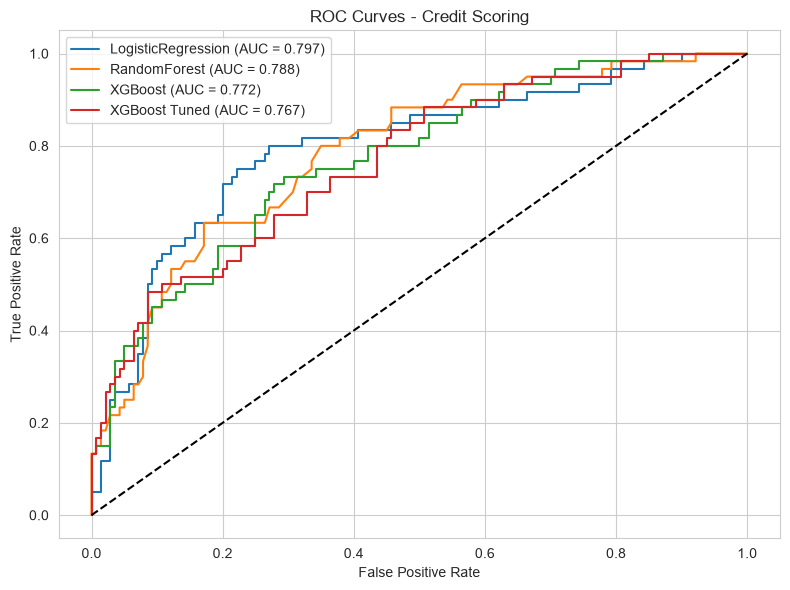

In [7]:
# 6. Comparaison des modèles (ROC curves)
plot_roc_curves(results, save_path="../roc_curves.png")

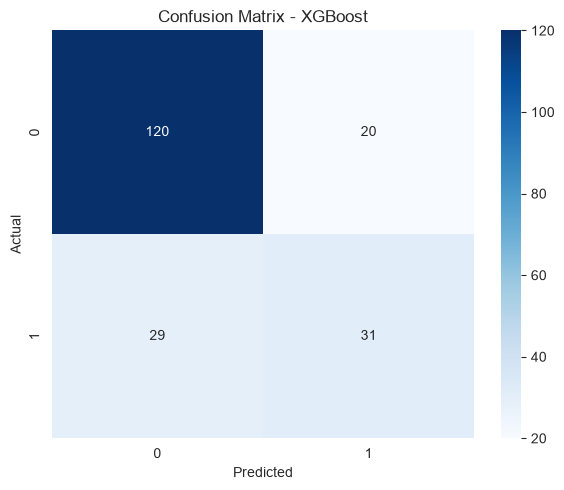

In [8]:
# 7. Matrice de confusion du meilleur modèle
plot_confusion_matrix(best_xgb, X_test, y_test, model_name="XGBoost",
                     save_path="../confusion_matrix_xgboost.png")

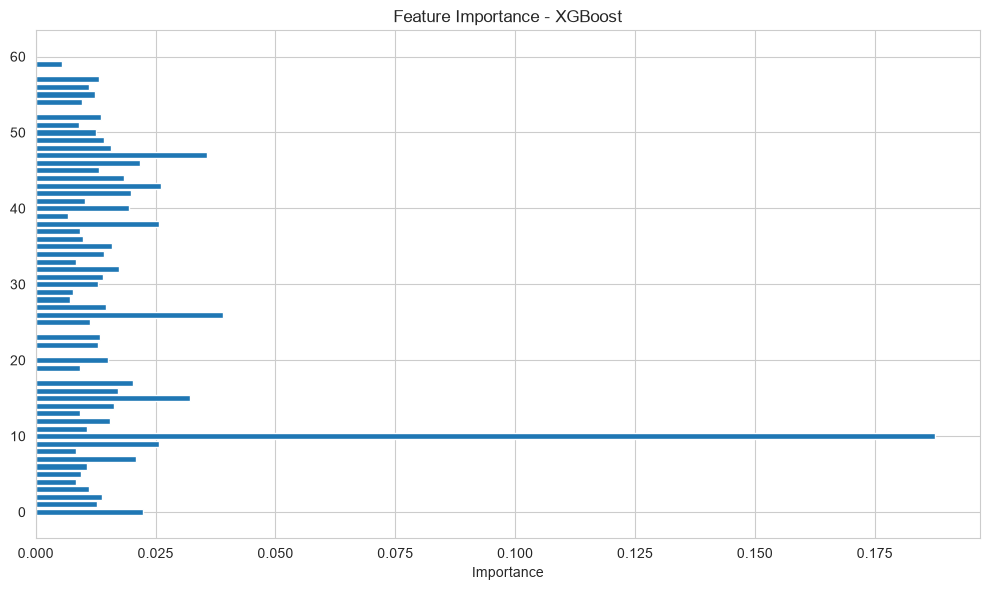

In [9]:
# 8. Feature Importance (XGBoost)
importances = best_xgb.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../feature_importance.png", dpi=150)
plt.show()

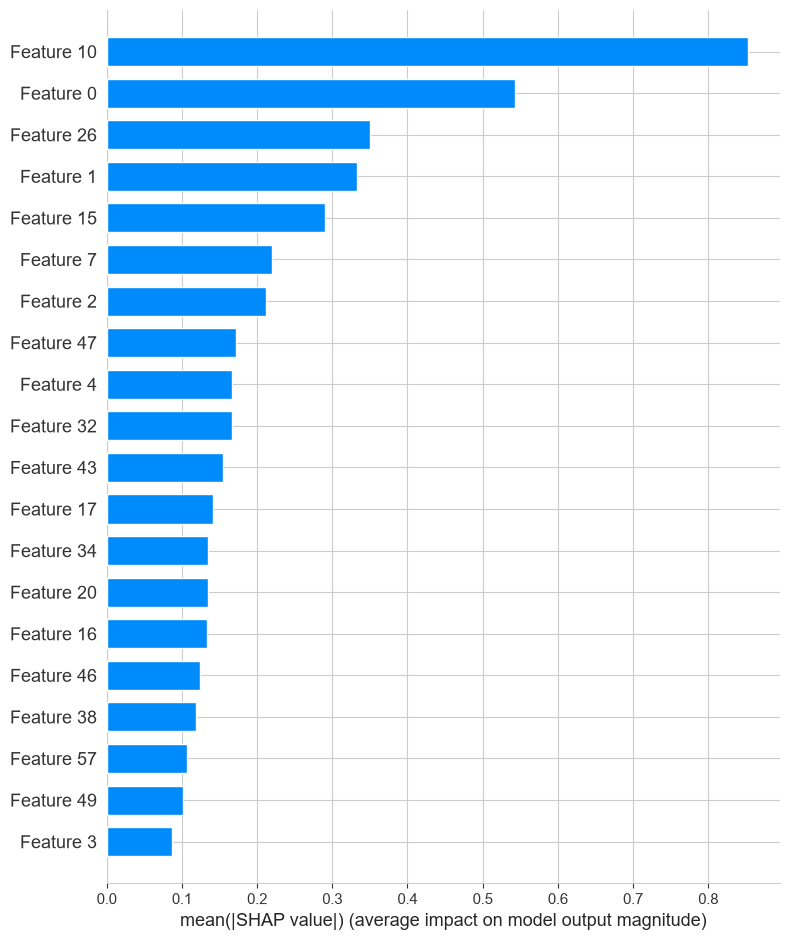

In [10]:
# 9. Interprétation SHAP (très valorisé par les recruteurs)
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Graphique global
shap.summary_plot(shap_values, X_test, plot_type="bar")